<a href="https://colab.research.google.com/github/LukeBarboza/AI-Codes/blob/HandsOn_Regression/Linear_Regression_HandsOn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.linear_model import LogisticRegression

import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.base import clone

In [3]:
#REGRESSÃO LINEAR FEITA NA MÃO
#Testando equação normal
#Gerando dados lineares para testar a equação
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [4]:
X_b = np.c_[np.ones((100, 1)), X] # adiciona x0 = 1 em cada instância
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[3.87788493],
       [2.96123843]])

In [5]:
#Realizando predições
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] #adiciona x0 = 1 para cada instância
y_predict = X_new_b.dot(theta_best)
y_predict

array([[3.87788493],
       [9.80036179]])

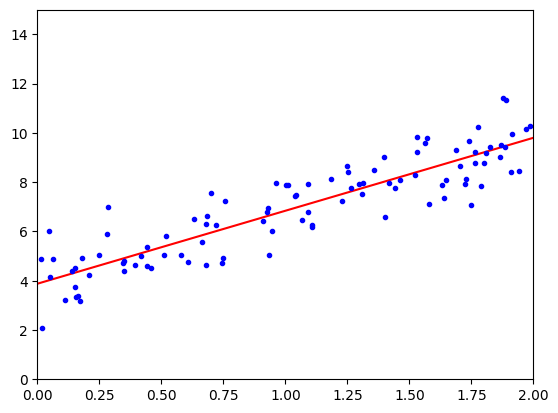

In [6]:
#Plotando predições
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [7]:
#REGRESSÃO LINEAR USANDO SCIKIT LEARN

In [8]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.87788493]), array([[2.96123843]]))

In [9]:
lin_reg.predict(X_new)

array([[3.87788493],
       [9.80036179]])

In [10]:
#Chamando diretamente lstsq (minimos quadrados) no lugar da LinearRegression
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.87788493],
       [2.96123843]])

In [11]:
#Implementação gradiente descendente
eta = 0.1 #taxa de aprendizado
n_iterations = 1000
m = 100

theta = np.random.randn(2, 1)

for iteration in range(n_iterations):
    gradients = (2 / m) * X_b.T.dot(X_b.dot(theta) - y)  # cálculo do gradiente
    theta = theta - eta * gradients  # atualização de theta
theta

array([[3.87788493],
       [2.96123843]])

In [12]:
#Implementand o Gradiente Descendente estocástico

n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
  return t0 / (t + t1)

theta = np.random.randn(2,1) #Inicialização aleatória

for epoch in range(n_epochs):
  for i in range(m):
    random_index = np.random.randint(m)
    xi = X_b[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
    eta = learning_schedule(epoch * m + i)
    theta = theta - eta * gradients

In [13]:
theta

array([[3.89891887],
       [2.91250277]])

In [14]:
#Usando o gradiente estocastico do SCIKIT Learn

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

SGDRegressor(eta0=0.1, penalty=None)

In [15]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.90236916]), array([2.99697799]))

In [16]:
#Adicionando potências para cada caracteristica para transformá-la em uma regressão polinimial

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

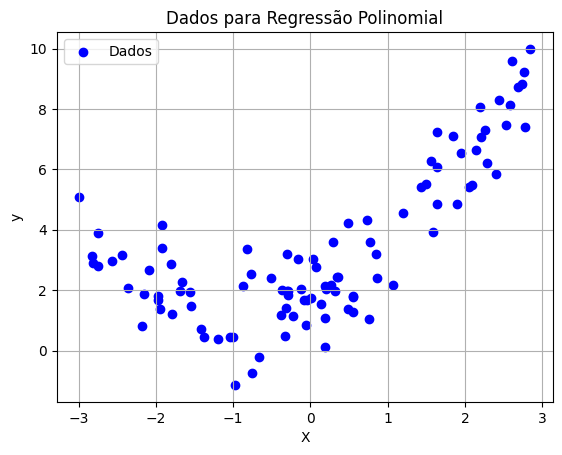

In [17]:
#Plotando dados simulados acima:
# Criando o gráfico
plt.scatter(X, y, color="blue", label="Dados")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dados para Regressão Polinomial")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-1.00852035])

In [19]:
X_poly[0]

array([-1.00852035,  1.01711329])

In [20]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.80069969]), array([[1.03765566, 0.57675559]]))

In [21]:
#Uma forma de ver é cross validation para ver overfitting e underfitting

#Outra forma é, no caso da regressão polinomial, analisar a curva de aprendizado (plotando a mesma)

def plot_learning_curves(model, X, y):
  X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
  train_errors, val_errors = [], []

  for m in range(1, len(X_train)):
    model.fit(X_train[:m], y_train[:m])
    y_train_predict = model.predict(X_train[:m])
    y_val_predict = model.predict(X_val)
    train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
    val_errors.append(mean_squared_error(y_val, y_val_predict))

  plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
  plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")

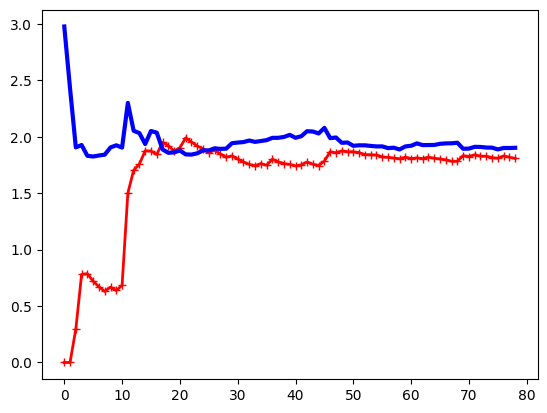

In [22]:
#Vendo grafico plotado.
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

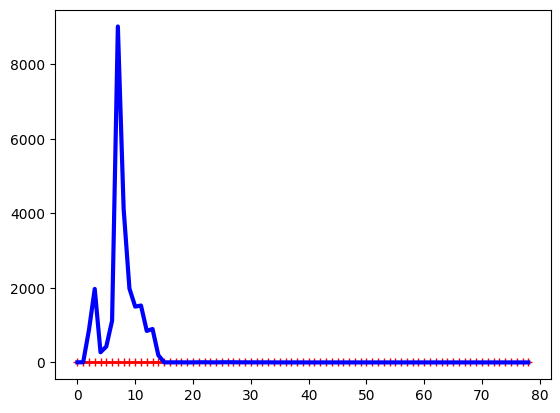

In [23]:
polynomial_regression = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("lin_reg", LinearRegression()),
])

plot_learning_curves(polynomial_regression, X, y)

In [24]:
#Uma maneira de evitar o overfitting é restringir o modelo.

#Ridge --> É como se aproximasse os pontos, ou como se engrossasse a linha isso faz com que seja mais suavizado MAS SEM CORTAR NADA APENAS SUAVIZA-OS.

ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([4.92988391])

In [25]:
#usando ridge com gradiente estocástico
sgd_reg = SGDRegressor(penalty="l2")
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([4.93430701])

In [26]:
#LASSO --> É como se aproximasse os pontos, ou como se engrossasse a linha isso faz com que seja mais suavizado MAS CORTANDO E FORÇANDO-OS à Zero.
lasso_reg = Lasso(alpha=0.1) # sgd_reg = SGDRegressor(penalty="l1") Gradiente descendente com LASSO
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([4.8807304])

In [27]:
#Elastic NET -> Meio termo entre LASSO E RIDGE (É preferivel utilizar esta ao invés da LASSO, porque a lasso é imprevisivel).

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([4.8791582])

In [40]:
#Early Stopping -> parar o treinamento assim que o errode validação atingir o minimo.
#prepara os dados

def early_stopping_sgd(X_train, y_train, X_val, y_val, model, max_epochs=1000, learning_rate=0.0005):
    """
    Treina um modelo com Early Stopping baseado no erro de validação.

    Parameters:
    - X_train: Dados de treinamento
    - y_train: Rótulos de treinamento
    - X_val: Dados de validação
    - y_val: Rótulos de validação
    - model: Modelo a ser treinado (ex: SGDRegressor)
    - max_epochs: Número máximo de épocas
    - learning_rate: Taxa de aprendizado (eta0)

    Retorna:
    - best_model: O modelo com o menor erro de validação
    - best_epoch: A época em que o erro de validação foi o menor
    """
    minimum_val_error = float("inf")
    best_epoch = None
    best_model = None

    for epoch in range(max_epochs):
        # Treinamento contínuo
        model.fit(X_train, y_train)

        # Predição e cálculo do erro de validação
        y_val_predict = model.predict(X_val)
        val_error = mean_squared_error(y_val, y_val_predict)

        # Se o erro de validação melhorar, salva o modelo
        if val_error < minimum_val_error:
            minimum_val_error = val_error
            best_epoch = epoch
            best_model = clone(model)  # Salva o melhor modelo

    return best_model, best_epoch

In [44]:
# Exemplo de como usar a função com o seu modelo e dados:

# Definindo X, y, X_val_poly_scaled, y_val e o modelo
X = np.array([[1, 2], [3, 4], [5, 6]])  # Exemplo de dados de treino
y = np.array([[1], [2], [3]])  # Rótulos de treino
X_val_poly_scaled = np.array([[1.5, 2.5], [3.5, 4.5]])  # Exemplo de dados de validação
y_val = np.array([1.5, 2.5])  # Rótulos de validação

# Definindo o modelo
sgd_reg = SGDRegressor(
    max_iter=1,
    tol=None,  # Corrigido aqui: removido -np.infty
    warm_start=True,
    penalty=None,
    learning_rate="constant",
    eta0=0.0005
)

# Chamada da função com Early Stopping
best_model, best_epoch = early_stopping_sgd(X, y.ravel(), X_val_poly_scaled, y_val, sgd_reg)

print(f"Melhor modelo encontrado na época {best_epoch}")

Melhor modelo encontrado na época 999


In [28]:
#Regressão Logistica (Categorizando por regressão -> se pertence a uma classe 1 se não 0)
#Usando um conjunto famoso de flores petalas setosas, versicolos, virginicas

iris = datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [30]:
X = iris["data"][:, 3:] # largura da pétala
y = (iris["target"] == 2).astype(np.int64)

In [33]:
log_reg = LogisticRegression()
log_reg.fit(X, y)

LogisticRegression()

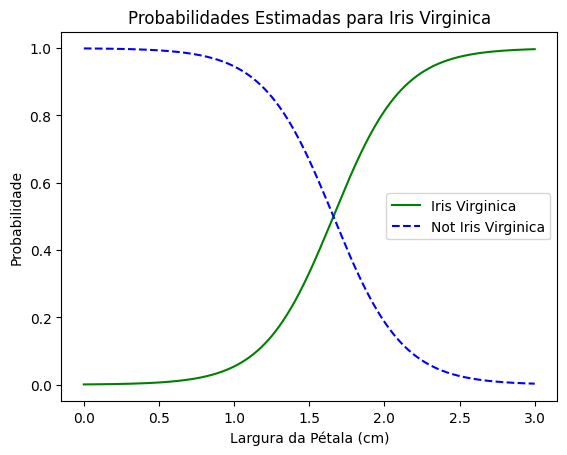

In [35]:
#Analisando probabilidades estimadas do modelo de flores com a largura das petalas variando de 0 a 3cm

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:, 1], "g-", label="Iris Virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris Virginica")

# Títulos e rótulos
plt.title("Probabilidades Estimadas para Iris Virginica")
plt.xlabel("Largura da Pétala (cm)")
plt.ylabel("Probabilidade")
plt.legend()

# Mostrar o gráfico
plt.show()

In [36]:
#Usando predict para identificar se é ou não uma lotus virginica
log_reg.predict([[1.7], [1.5]])

array([1, 0])

In [37]:
#Regressão SoftMax Usada quanto temos mais de uma classe virginica, Setosa, virginica.

X = iris["data"][:, (2,3)] #Comprimento da pétala, largura da pétala.
y = iris["target"]

softmax_reg = LogisticRegression(multi_class="multinomial", solver="lbfgs", C=10)
softmax_reg.fit(X, y)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=10, multi_class='multinomial')

In [38]:
#Vendo resultado da previsão
softmax_reg.predict([[5, 2]])

array([2])

In [39]:
softmax_reg.predict_proba([[5, 2]])

array([[6.21626375e-07, 5.73689803e-02, 9.42630398e-01]])